# vgridpandas examples

The three visual examples from the [vgridpandas PyPI page](https://pypi.org/project/vgridpandas/), with the docs' bugs fixed.

**Gotchas fixed here:**
- `latlon2h3` wants `lng_col` (the page shows a duplicate `lat_col`).
- `h3bin`/`a5bin` want `lon_col` instead — the API is inconsistent across modules.
- `s2.polyfill` returns one row with a *list* of cell IDs; `.explode()` it before `s22geo` to get one polygon per cell.
- The page's `a5bin` crashes in the current build (`a5` dependency mismatch), so example 3 uses `h3bin` — same idea. Try `a5bin` again after `pip install --upgrade a5 vgrid`.

Data here is synthetic so the notebook runs offline. The real dataset URLs from the page are included as commented lines — uncomment them if you have internet.

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from vgridpandas import h3pandas, s2pandas, a5pandas

np.random.seed(7)

## 1. Latlong -> H3 -> geometry

Snap points to H3 cells, then turn each cell ID into its hexagon polygon. Two points a full degree apart at resolution 10 give two tiny, far-apart hexagons - dull on purpose; the later examples are where a grid becomes visible.

                 lat  lon  h3_res  \
h3                                  
8a65a212199ffff   10  106      10   
8a65b0b68237fff   11  107      10   

                                                          geometry  
h3                                                                  
8a65a212199ffff  POLYGON ((106.00123 9.99977, 106.0013 10.00051...  
8a65b0b68237fff  POLYGON ((107.00078 10.99902, 107.00086 10.999...  


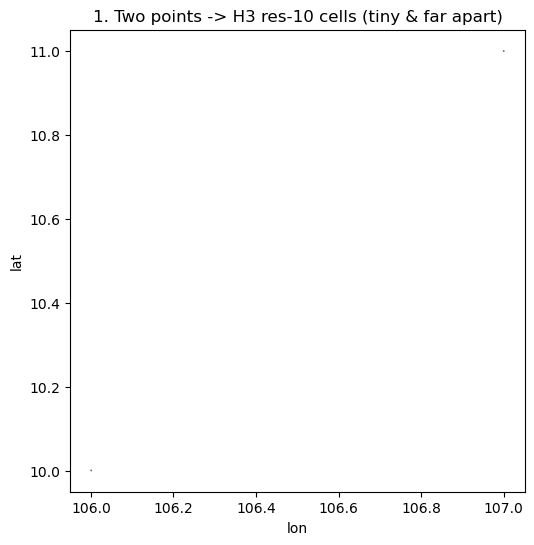

In [3]:
df = pd.DataFrame({'lat': [10, 11], 'lon': [106, 107]})
df = df.h3.latlon2h3(10, lat_col='lat', lng_col='lon')   # adds 'h3' cell-id index
df = df.h3.h32geo()                                       # adds hexagon 'geometry'
print(df)

ax = df.plot(edgecolor='black', facecolor='tab:blue', alpha=0.6, figsize=(6, 6))
ax.set_title('1. Two points -> H3 res-10 cells (tiny & far apart)')
ax.set_xlabel('lon'); ax.set_ylabel('lat')
plt.show()

## 2. Polygon -> S2 polyfill (compact)

Fill a polygon with S2 cells. `compact=True` covers the interior with a few big cells and only shrinks cells near the boundary - that mixed-size look is the point of compaction. `polyfill` returns a list of cell IDs per row, so `.explode()` before `s22geo`.

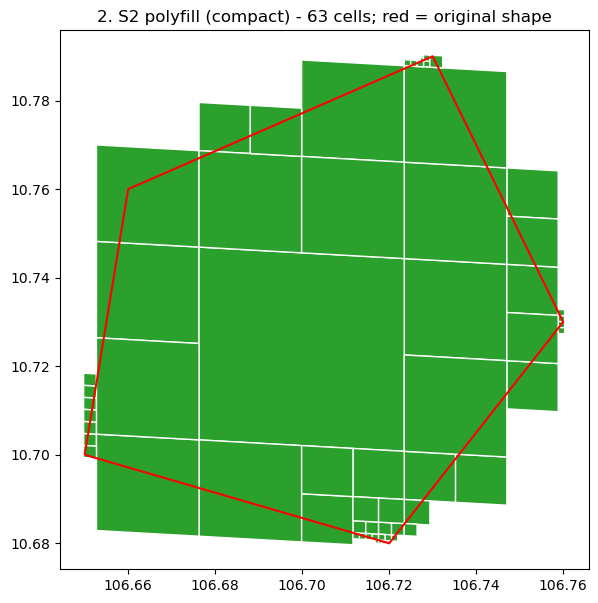

In [4]:
# Real data from the page (uncomment if online):
# gdf = gpd.read_file('https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polygon.geojson')
poly = Polygon([(106.66, 10.76), (106.73, 10.79), (106.76, 10.73),
                (106.72, 10.68), (106.65, 10.70)])
gdf = gpd.GeoDataFrame({'name': ['zone']}, geometry=[poly], crs='EPSG:4326')

gdf_fill = gdf.s2.polyfill(18, compact=True, predicate='intersects')
gdf_fill = gdf_fill.explode('s2')       # list of cell-ids -> one id per row
gdf_fill = gdf_fill.s2.s22geo('s2')     # one polygon per cell

ax = gdf_fill.plot(edgecolor='white', facecolor='tab:green', figsize=(7, 7))
gdf.boundary.plot(ax=ax, color='red', linewidth=1.5)
ax.set_title(f'2. S2 polyfill (compact) - {len(gdf_fill)} cells; red = original shape')
plt.show()

## 3. Point binning -> H3 cells colored by count

The killer feature: aggregate thousands of points into cells and color by a statistic - an instant hex heatmap. The page uses `a5bin`; this uses `h3bin` (identical API/idea) because `a5bin` has a dependency bug in the current build.

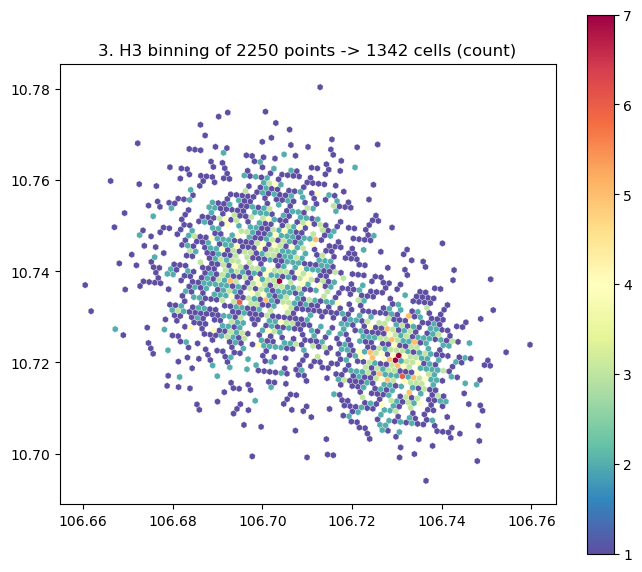

In [12]:
# Real data from the page (uncomment if online):
# pois = pd.read_csv('https://raw.githubusercontent.com/opengeoshub/vopendata/refs/heads/main/csv/dist1_pois.csv')
n = 1500
cx, cy = 106.70, 10.74
lon = np.concatenate([np.random.normal(cx, 0.012, n),
                      np.random.normal(cx + 0.03, 0.008, n // 2)])
lat = np.concatenate([np.random.normal(cy, 0.012, n),
                      np.random.normal(cy - 0.02, 0.008, n // 2)])
pois = pd.DataFrame({'lat': lat, 'lon': lon})

# Note: h3bin/a5bin use lon_col (not lng_col like latlon2h3)
df_bin = pois.h3.h3bin(resolution=10, stats='count',
                       lat_col='lat', lon_col='lon', return_geometry=True)

ax = df_bin.plot(column='count', cmap='Spectral_r', legend=True,
                 linewidth=0.2, edgecolor='white', figsize=(8, 7))
ax.set_title(f'3. H3 binning of {len(pois)} points -> {len(df_bin)} cells (count)')
plt.show()